# Solutions: Notebook 02 — Multiple Quantiles and the Quantile Process

Complete solutions to all exercises from Notebook 02.

In [1]:
# Setup (same as main notebook)
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

from scipy import stats

from panelbox import PooledOLS
from panelbox.models.quantile import PooledQuantile

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

np.random.seed(42)

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

# Load data
data = pd.read_csv(DATA_DIR / "card_education.csv")

# Prepare arrays
y = data["lwage"].values
var_names = ["const", "female", "educ", "exper", "exper_sq"]

X_df = pd.DataFrame(
    {
        "const": np.ones(len(data)),
        "female": data["female"].values,
        "educ": data["educ"].values,
        "exper": data["exper"].values,
        "exper_sq": data["exper"].values ** 2,
    }
)
X = X_df.values
entity_id = data["id"].values

# Estimate quantile process
tau_grid = np.arange(0.05, 0.96, 0.05)
tau_keys = [round(t, 2) for t in tau_grid]

qr_results = {}
for tau in tau_keys:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    qr_results[tau] = model.fit(se_type="cluster")

# OLS
ols_model = PooledOLS(
    "lwage ~ female + educ + exper + I(exper**2)", data, entity_col="id", time_col="year"
)
ols_result = ols_model.fit(cov_type="clustered")

ols_var_map = {
    "const": "Intercept",
    "female": "female",
    "educ": "educ",
    "exper": "exper",
    "exper_sq": "I(exper ** 2)",
}

print("Setup and estimation complete!")

Setup and estimation complete!


In [2]:
# Helper function from main notebook
def inter_quantile_test(var_idx, tau1, tau2, results_dict):
    """Test H0: beta(tau1) = beta(tau2) using Wald test."""
    beta1 = results_dict[tau1].params.ravel()[var_idx]
    beta2 = results_dict[tau2].params.ravel()[var_idx]
    se1 = results_dict[tau1].std_errors.ravel()[var_idx]
    se2 = results_dict[tau2].std_errors.ravel()[var_idx]

    diff = beta2 - beta1
    se_diff = np.sqrt(se1**2 + se2**2)
    t_stat = diff / se_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

    return {
        "beta_tau1": beta1,
        "beta_tau2": beta2,
        "diff": diff,
        "se": se_diff,
        "t_stat": t_stat,
        "p_value": p_value,
        "significant": p_value < 0.05,
    }


print("Helper function defined.")

Helper function defined.


---

## Exercise 1: Conceptual Understanding (Easy)

**Question**: Explain why the OLS coefficient can be thought of a "weighted average" of quantile regression coefficients. Under what conditions would OLS and QR (τ=0.5) give identical results?

In [3]:
# Exercise 1: Solution

print("SOLUTION: OLS as a Weighted Average of QR Coefficients")
print("=" * 60)
print()
print("1. OLS as Weighted Average:")
print("   - OLS minimizes E[(Y - X'b)^2], which estimates E(Y|X).")
print("   - The mean of Y can be expressed as an integral over the")
print("   quantile function: E(Y|X) = integral_0^1 Q_tau(Y|X) dtau")
print("   - If the quantile regression model is correctly specified")
print("   (Q_tau(Y|X) = X'beta(tau)), then:")
print("   beta_OLS = integral_0^1 beta(tau) dtau")
print("   - In practice, OLS coefficient is approximately the")
print("   (equally-weighted) average of QR coefficients.")
print()
print("2. Conditions for OLS = QR(0.5):")
print("   a) The error distribution is SYMMETRIC (mean = median).")
print("   b) Specifically, if Y|X has a symmetric distribution,")
print("      then E(Y|X) = Q_0.5(Y|X), so OLS = median regression.")
print("   c) Examples: Normal, Uniform, Student-t distributions.")
print("   d) NOT true for: Log-normal, Chi-squared, Exponential.")
print()

# Numerical verification
print("Numerical Verification:")
print(f"  OLS (educ):    {ols_result.params['educ']:.4f}")

educ_idx = var_names.index("educ")
educ_coefs = [qr_results[tau].params.ravel()[educ_idx] for tau in tau_keys]
avg_qr = np.mean(educ_coefs)
print(f"  Average QR:    {avg_qr:.4f}")
print(f"  QR(0.5):       {qr_results[0.5].params.ravel()[educ_idx]:.4f}")
print(f"  Difference (OLS vs avg QR): {ols_result.params['educ'] - avg_qr:.4f}")

SOLUTION: OLS as a Weighted Average of QR Coefficients

1. OLS as Weighted Average:
   - OLS minimizes E[(Y - X'b)^2], which estimates E(Y|X).
   - The mean of Y can be expressed as an integral over the
   quantile function: E(Y|X) = integral_0^1 Q_tau(Y|X) dtau
   - If the quantile regression model is correctly specified
   (Q_tau(Y|X) = X'beta(tau)), then:
   beta_OLS = integral_0^1 beta(tau) dtau
   - In practice, OLS coefficient is approximately the
   (equally-weighted) average of QR coefficients.

2. Conditions for OLS = QR(0.5):
   a) The error distribution is SYMMETRIC (mean = median).
   b) Specifically, if Y|X has a symmetric distribution,
      then E(Y|X) = Q_0.5(Y|X), so OLS = median regression.
   c) Examples: Normal, Uniform, Student-t distributions.
   d) NOT true for: Log-normal, Chi-squared, Exponential.

Numerical Verification:
  OLS (educ):    0.0775
  Average QR:    0.0806
  QR(0.5):       0.0880
  Difference (OLS vs avg QR): -0.0030


---

## Exercise 2: Implementation (Easy)

**Task**: Extract the quantile process for education, test homogeneity, plot, and interpret.

Test H0: beta_educ(0.25) = beta_educ(0.75)
  beta(0.25) = 0.0382
  beta(0.75) = 0.1368
  Difference = 0.0986
  t-statistic = 84.86
  p-value = 0.000000
  Result: REJECT H0


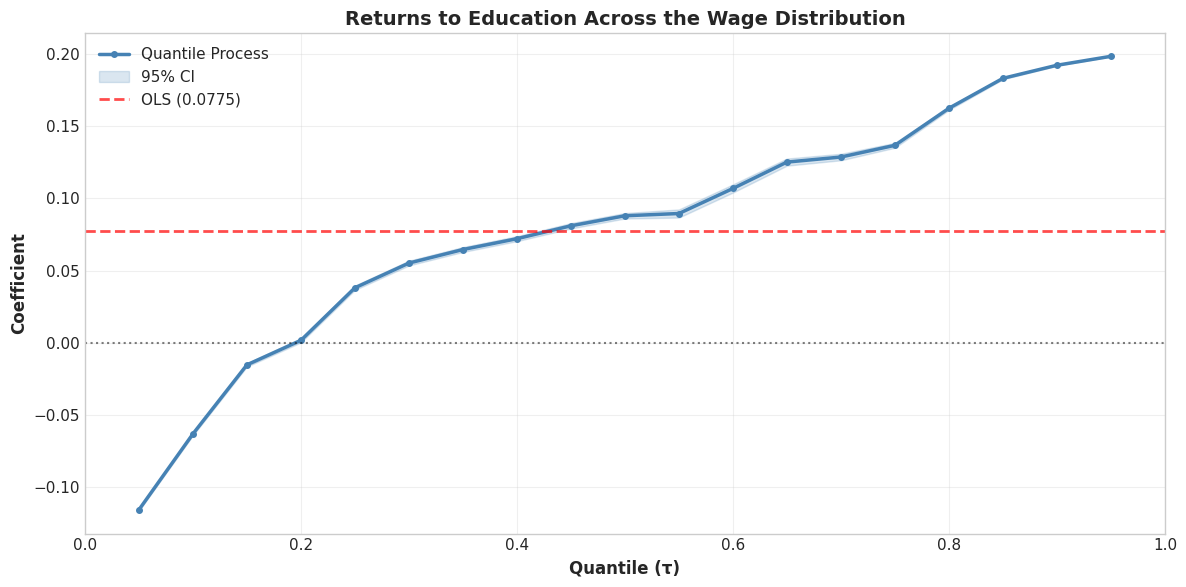


Interpretation:
Education returns increase with quantile level.
This means education benefits high-wage workers MORE
than low-wage workers => education AMPLIFIES inequality.
The interquantile range (0.25 to 0.75) difference of 0.0986
is statistically significant (p=0.0000).


In [4]:
# Exercise 2: Solution - Education quantile process

educ_idx = var_names.index("educ")

# Extract coefficients and SEs for education across tau_keys
educ_coefs = [qr_results[tau].params.ravel()[educ_idx] for tau in tau_keys]
educ_ses = [qr_results[tau].std_errors.ravel()[educ_idx] for tau in tau_keys]
educ_ci_lower = [c - 1.96 * s for c, s in zip(educ_coefs, educ_ses)]
educ_ci_upper = [c + 1.96 * s for c, s in zip(educ_coefs, educ_ses)]

# Test H0: beta_educ(0.25) = beta_educ(0.75)
result = inter_quantile_test(educ_idx, 0.25, 0.75, qr_results)
print("Test H0: beta_educ(0.25) = beta_educ(0.75)")
print("=" * 50)
print(f"  beta(0.25) = {result['beta_tau1']:.4f}")
print(f"  beta(0.75) = {result['beta_tau2']:.4f}")
print(f"  Difference = {result['diff']:.4f}")
print(f"  t-statistic = {result['t_stat']:.2f}")
print(f"  p-value = {result['p_value']:.6f}")
print(f"  Result: {'REJECT H0' if result['significant'] else 'FAIL TO REJECT H0'}")

# Create coefficient path plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    tau_keys,
    educ_coefs,
    linewidth=2.5,
    color="steelblue",
    marker="o",
    markersize=4,
    label="Quantile Process",
)
ax.fill_between(
    tau_keys, educ_ci_lower, educ_ci_upper, alpha=0.2, color="steelblue", label="95% CI"
)

ols_educ = ols_result.params["educ"]
ax.axhline(
    ols_educ, color="red", linestyle="--", linewidth=2, label=f"OLS ({ols_educ:.4f})", alpha=0.7
)
ax.axhline(0, color="black", linestyle=":", alpha=0.5)

ax.set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
ax.set_ylabel("Coefficient", fontsize=12, fontweight="bold")
ax.set_title("Returns to Education Across the Wage Distribution", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
print("Education returns increase with quantile level.")
print("This means education benefits high-wage workers MORE")
print("than low-wage workers => education AMPLIFIES inequality.")
print(f"The interquantile range (0.25 to 0.75) difference of {result['diff']:.4f}")
print(f"is statistically significant (p={result['p_value']:.4f}).")

---

## Exercise 3: Inter-Quantile Testing (Medium)

**Given** union_member results: β(0.1)=0.12 (SE=0.02), β(0.5)=0.15 (SE=0.015), β(0.9)=0.09 (SE=0.03)

In [5]:
# Exercise 3: Solution

# Given data
beta_01 = 0.12
se_01 = 0.02
beta_05 = 0.15
se_05 = 0.015
beta_09 = 0.09
se_09 = 0.03

# a) Test H0: beta(0.1) = beta(0.9)
print("a) Test H0: beta(0.1) = beta(0.9)")
print("=" * 50)
diff = beta_09 - beta_01
se_diff = np.sqrt(se_01**2 + se_09**2)
t_stat = diff / se_diff
p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

print(f"  beta(0.1) = {beta_01}")
print(f"  beta(0.9) = {beta_09}")
print(f"  Difference = {diff:.4f}")
print(f"  SE(diff) = {se_diff:.4f}")
print(f"  t-statistic = {t_stat:.2f}")
print(f"  p-value = {p_value:.4f}")
print(f"  Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'}")
print(f"  The difference is {'' if p_value < 0.05 else 'NOT '}statistically significant.")

# b) Pattern interpretation
print("\nb) Interpretation of the Inverted-U Pattern:")
print("=" * 50)
print("  The union effect follows an INVERTED-U shape:")
print(f"    tau=0.1: beta = {beta_01} (moderate effect at bottom)")
print(f"    tau=0.5: beta = {beta_05} (largest effect at median)")
print(f"    tau=0.9: beta = {beta_09} (smallest effect at top)")
print()
print("  This suggests unions COMPRESS the wage distribution:")
print("  - They help middle-wage workers the most (largest premium).")
print("  - They help top earners the least (possibly because top earners")
print("    already negotiate individually above union rates).")
print("  - The union effect is INEQUALITY-REDUCING (compresses distribution).")

# c) Would OLS miss heterogeneity?
print("\nc) Would OLS Miss Important Heterogeneity?")
print("=" * 50)
# OLS would give approximately the average: (0.12 + 0.15 + 0.09) / 3 = 0.12
ols_approx = (beta_01 + beta_05 + beta_09) / 3
print(f"  OLS would estimate approximately: {ols_approx:.3f}")
print(f"  This is close to the median effect ({beta_05}), but:")
print("  - It MISSES the inverted-U shape entirely.")
print("  - It would suggest a uniform 12% union premium.")
print("  - It would not reveal that unions compress wages.")
print("  - YES, OLS misses important heterogeneity about the")
print("    distributional effects of unions.")

a) Test H0: beta(0.1) = beta(0.9)
  beta(0.1) = 0.12
  beta(0.9) = 0.09
  Difference = -0.0300
  SE(diff) = 0.0361
  t-statistic = -0.83
  p-value = 0.4054
  Result: FAIL TO REJECT H0
  The difference is NOT statistically significant.

b) Interpretation of the Inverted-U Pattern:
  The union effect follows an INVERTED-U shape:
    tau=0.1: beta = 0.12 (moderate effect at bottom)
    tau=0.5: beta = 0.15 (largest effect at median)
    tau=0.9: beta = 0.09 (smallest effect at top)

  This suggests unions COMPRESS the wage distribution:
  - They help middle-wage workers the most (largest premium).
  - They help top earners the least (possibly because top earners
    already negotiate individually above union rates).
  - The union effect is INEQUALITY-REDUCING (compresses distribution).

c) Would OLS Miss Important Heterogeneity?
  OLS would estimate approximately: 0.120
  This is close to the median effect (0.15), but:
  - It MISSES the inverted-U shape entirely.
  - It would suggest a un

---

## Exercise 4: Bandwidth Analysis (Medium)

**Task**: Compute and plot the bandwidth (slope) for education. Interpret inequality effects.

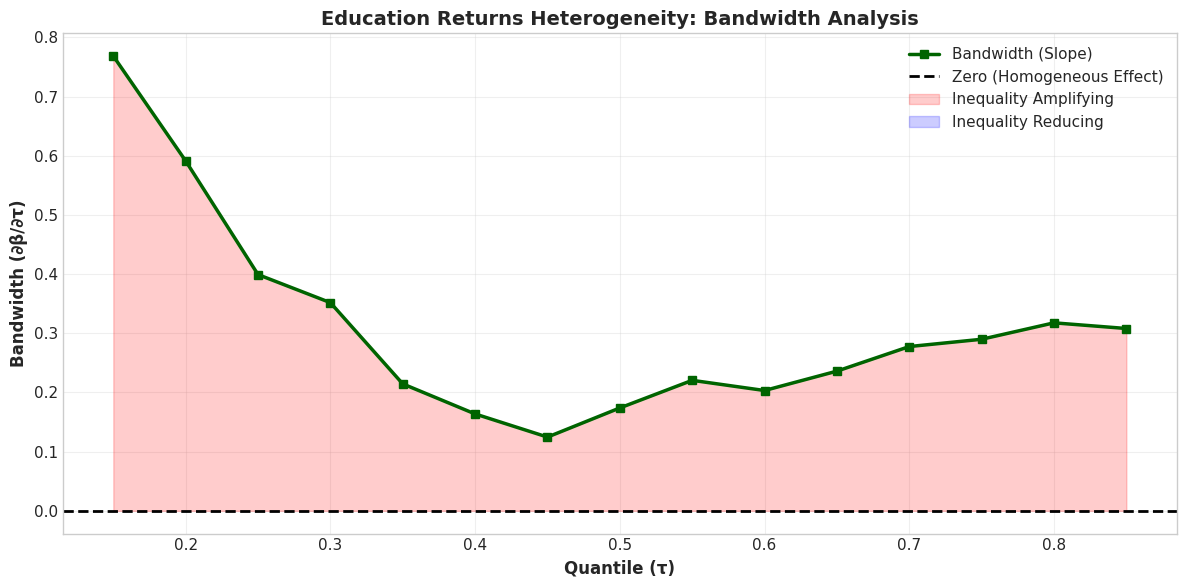


Average bandwidth for education: 0.3093
Education returns INCREASE with quantile level.
=> Education is INEQUALITY-AMPLIFYING.
=> High-wage workers benefit more from education than low-wage workers.
=> Education widens the wage distribution.


In [6]:
# Exercise 4: Solution - Bandwidth analysis for education

h = 0.10
educ_idx = var_names.index("educ")

# Compute bandwidths
bandwidths_educ = {}
tau_bw = [t for t in tau_keys if t >= 0.15 and t <= 0.85]

for tau in tau_bw:
    tau_low = round(tau - h, 2)
    tau_high = round(tau + h, 2)

    if tau_low in qr_results and tau_high in qr_results:
        beta_low = qr_results[tau_low].params.ravel()[educ_idx]
        beta_high = qr_results[tau_high].params.ravel()[educ_idx]
        bandwidths_educ[tau] = (beta_high - beta_low) / (2 * h)

bw_taus_e = list(bandwidths_educ.keys())
bw_vals_e = list(bandwidths_educ.values())
bw_array_e = np.array(bw_vals_e)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    bw_taus_e,
    bw_vals_e,
    linewidth=2.5,
    color="darkgreen",
    marker="s",
    markersize=6,
    label="Bandwidth (Slope)",
)

ax.axhline(0, color="black", linestyle="--", linewidth=2, label="Zero (Homogeneous Effect)")

ax.fill_between(
    bw_taus_e,
    0,
    bw_vals_e,
    where=bw_array_e > 0,
    alpha=0.2,
    color="red",
    label="Inequality Amplifying",
)

ax.fill_between(
    bw_taus_e,
    0,
    bw_vals_e,
    where=bw_array_e < 0,
    alpha=0.2,
    color="blue",
    label="Inequality Reducing",
)

ax.set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
ax.set_ylabel("Bandwidth (\u2202\u03b2/\u2202\u03c4)", fontsize=12, fontweight="bold")
ax.set_title("Education Returns Heterogeneity: Bandwidth Analysis", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
avg_bw_educ = np.mean(bw_vals_e)
print(f"\nAverage bandwidth for education: {avg_bw_educ:.4f}")
if avg_bw_educ > 0:
    print("Education returns INCREASE with quantile level.")
    print("=> Education is INEQUALITY-AMPLIFYING.")
    print("=> High-wage workers benefit more from education than low-wage workers.")
    print("=> Education widens the wage distribution.")
elif avg_bw_educ < 0:
    print("Education returns DECREASE with quantile level.")
    print("=> Education is INEQUALITY-REDUCING.")
else:
    print("Education returns are approximately CONSTANT.")
    print("=> Education is INEQUALITY-NEUTRAL.")

---

## Exercise 5: Glass Ceiling Test (Hard)

**Task**: Formal test for glass ceiling hypothesis.

In [7]:
# Exercise 5: Solution - Formal glass ceiling test

female_idx = var_names.index("female")

# Split female coefficients into two groups
group_low_taus = [t for t in tau_keys if t <= 0.70]
group_high_taus = [t for t in tau_keys if t > 0.70]

group_low_coefs = [qr_results[tau].params.ravel()[female_idx] for tau in group_low_taus]
group_high_coefs = [qr_results[tau].params.ravel()[female_idx] for tau in group_high_taus]

# Compute average coefficient for each group
avg_low = np.mean(group_low_coefs)
avg_high = np.mean(group_high_coefs)

print("Glass Ceiling Hypothesis Test")
print("=" * 55)
print(f"Group 1 (tau <= 0.70): {len(group_low_taus)} quantiles")
print(f"  Taus: {group_low_taus}")
print(f"  Average female coef: {avg_low:.4f}")
print(f"\nGroup 2 (tau > 0.70): {len(group_high_taus)} quantiles")
print(f"  Taus: {group_high_taus}")
print(f"  Average female coef: {avg_high:.4f}")

# Test: Is the high-quantile group more negative than the low-quantile group?
# H0: avg(group_high) >= avg(group_low)  [no glass ceiling]
# H1: avg(group_high) < avg(group_low)   [glass ceiling exists]

# Use pooled SE from the individual quantile SEs
se_low = [qr_results[tau].std_errors.ravel()[female_idx] for tau in group_low_taus]
se_high = [qr_results[tau].std_errors.ravel()[female_idx] for tau in group_high_taus]

# SE of the average = sqrt(mean(se_i^2) / n) approximately
se_avg_low = np.sqrt(np.mean(np.array(se_low) ** 2)) / np.sqrt(len(group_low_taus))
se_avg_high = np.sqrt(np.mean(np.array(se_high) ** 2)) / np.sqrt(len(group_high_taus))

# Difference test
diff = avg_high - avg_low
se_diff = np.sqrt(se_avg_low**2 + se_avg_high**2)
t_stat = diff / se_diff
p_value_one_sided = stats.norm.cdf(t_stat)  # one-sided: test if high is more negative

print("\nTest Statistics:")
print(f"  Difference (high - low): {diff:.4f}")
print(f"  SE(difference): {se_diff:.4f}")
print(f"  t-statistic: {t_stat:.2f}")
print(f"  p-value (one-sided): {p_value_one_sided:.4f}")
print()

if diff < 0 and p_value_one_sided < 0.05:
    print("CONCLUSION: Glass ceiling DETECTED.")
    print("The gender wage gap is significantly larger (more negative)")
    print("at high quantiles compared to low/mid quantiles.")
elif diff > 0:
    print("CONCLUSION: No glass ceiling detected.")
    print("Instead, evidence of a STICKY FLOOR effect:")
    print("the gender wage gap is larger at LOW quantiles.")
    print("This suggests barriers to women at the bottom of the distribution.")
else:
    print("CONCLUSION: No significant glass ceiling effect detected.")
    print("The gender wage gap does not vary significantly between")
    print("low/mid and high quantiles.")

Glass Ceiling Hypothesis Test
Group 1 (tau <= 0.70): 14 quantiles
  Taus: [np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7)]
  Average female coef: -0.2463

Group 2 (tau > 0.70): 5 quantiles
  Taus: [np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95)]
  Average female coef: -0.2176

Test Statistics:
  Difference (high - low): 0.0287
  SE(difference): 0.0015
  t-statistic: 18.68
  p-value (one-sided): 1.0000

CONCLUSION: No glass ceiling detected.
Instead, evidence of a STICKY FLOOR effect:
the gender wage gap is larger at LOW quantiles.
This suggests barriers to women at the bottom of the distribution.


---

## Exercise 6: Crossing Resolution (Hard)

**Scenario**: Crossing detected between τ=0.7 and τ=0.8.

In [8]:
# Exercise 6: Solution

print("SOLUTION: Crossing Resolution")
print("=" * 55)

print()
print("a) Three Possible Causes of Quantile Crossing:")
print("-" * 50)
print("  1. FINITE SAMPLE NOISE: With limited data, especially")
print("     at extreme quantiles, coefficient estimates have high")
print("     variance. Random fluctuations can cause adjacent")
print("     quantile predictions to swap order.")
print()
print("  2. MODEL MISSPECIFICATION: If the true conditional")
print("     quantile function is nonlinear but we estimate a")
print("     linear model, the linear approximation at different")
print("     quantiles may cross. For example, if the true model")
print("     has heteroskedastic errors that depend on X.")
print()
print("  3. SPARSE DATA AT TAILS: At high quantiles (tau > 0.7),")
print("     fewer observations contribute to the estimator.")
print("     The effective sample size is ~n*(1-tau) for tau near 1,")
print("     leading to imprecise estimates that may cross.")

print()
print("b) Diagnosing the Root Cause:")
print("-" * 50)
print("  Step 1: Check sample sizes near the crossing quantiles.")
print("          If n*(1-0.7)=0.3n is small, suspect finite sample noise.")
print()
print("  Step 2: Check crossing FREQUENCY across many test points X.")
print("          If crossing occurs for only a few X values, likely noise.")
print("          If widespread, likely misspecification.")
print()
print("  Step 3: Bootstrap the predictions and check if crossing")
print("          persists. If it appears in < 50% of bootstrap samples,")
print("          it is likely noise.")
print()
print("  Step 4: Test for heteroskedasticity. If Var(Y|X) depends")
print("          on X, a location-scale model may be more appropriate.")

print()
print("c) Two Solutions:")
print("-" * 50)
print("  Solution 1: LOCATION-SCALE MODEL (Notebook 05)")
print("    The Machado-Santos Silva (2019) location-scale approach")
print("    models Q_tau(Y|X) = X'mu + X'sigma * F^{-1}(tau).")
print("    This guarantees non-crossing by construction because")
print("    the quantile function is monotone in tau through F^{-1}.")
print()
print("  Solution 2: MONOTONICITY CORRECTION (Notebook 08)")
print("    Post-estimation corrections:")
print("    - Rearrangement: Sort predictions to enforce monotonicity.")
print("    - Isotonic regression: Project coefficient paths onto")
print("      the space of monotone functions.")
print("    - Constrained QR: Estimate with explicit non-crossing")
print("      constraints (computationally expensive).")

SOLUTION: Crossing Resolution

a) Three Possible Causes of Quantile Crossing:
--------------------------------------------------
  1. FINITE SAMPLE NOISE: With limited data, especially
     at extreme quantiles, coefficient estimates have high
     variance. Random fluctuations can cause adjacent
     quantile predictions to swap order.

  2. MODEL MISSPECIFICATION: If the true conditional
     quantile function is nonlinear but we estimate a
     linear model, the linear approximation at different
     quantiles may cross. For example, if the true model
     has heteroskedastic errors that depend on X.

  3. SPARSE DATA AT TAILS: At high quantiles (tau > 0.7),
     fewer observations contribute to the estimator.
     The effective sample size is ~n*(1-tau) for tau near 1,
     leading to imprecise estimates that may cross.

b) Diagnosing the Root Cause:
--------------------------------------------------
  Step 1: Check sample sizes near the crossing quantiles.
          If n*(1-0.7)=0